# Audyt i przygotowanie zbioru danych


Celem etapu jest przygotowanie zweryfikowanego i powtarzalnego zbioru danych do badań nad klasyfikacją znaków drogowych.

Analiza obejmuje:
- identyfikację struktury zbioru danych,
- charakterystykę liczności klas,
- kontrolę poprawności plików,
- analizę parametrów technicznych obrazów,
- wykrywanie identycznych duplikatów,
- kontrolę potencjalnego przecieku danych pomiędzy zbiorami,
- przygotowanie zbiorów `train`, `validation` i `test`,

Oryginalny zbiór danych pozostaje niezmodyfikowany.

In [ ]:
from pathlib import Path
import math
import hashlib
import json
import random
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

ImageFile.LOAD_TRUNCATED_IMAGES = True

SOURCE_DATASET_ROOT = Path(
    r"C:/Users/Dell/Desktop/Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych/"
    r"KB_Praca_Magisterska/data/raw/polish_traffic_signs_dataset"
)

PROJECT_ROOT = SOURCE_DATASET_ROOT.parents[1]

METADATA_DIR = PROJECT_ROOT / "data" / "processed" / "metadata"
REPORTS_DIR = PROJECT_ROOT / "reports" / "dataset_audit"
FIGURES_DIR = REPORTS_DIR / "figures"

for directory in [METADATA_DIR, REPORTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
VALIDATION_RATIO = 0.15

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff"
}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Źródło danych:", SOURCE_DATASET_ROOT)
print("Katalog projektu:", PROJECT_ROOT)

Źródło danych: C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\data\raw\polish_traffic_signs_dataset
Katalog projektu: C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\data


## 1. Zbiór danych.

Skorzystano z bazy polskich znaków drogowych udostępnionej na platformie 'kaggle’:  polish traffic signs dataset
https://www.kaggle.com/datasets/kasia12345/polish-traffic-signs-dataset/data


Nazwa katalogu zawierającego obrazy jest traktowana jako kod klasy znaku.


```text
polish_traffic_signs_dataset/
├── train/
│   ├── A-1/
│   ├── A-2/
│   └── ...
└── test/
    ├── A-1/
    ├── A-2/
    └── ...

In [ ]:
def find_split_dir(root: Path, split_name: str):
    direct = root / split_name
    if direct.is_dir():
        return direct
    matches = [
        path
        for path in root.rglob("*")
        if path.is_dir() and path.name.lower() == split_name.lower()
    ]
    return matches[0] if matches else None


def list_class_dirs(split_dir: Path):
    return sorted(
        [path for path in split_dir.iterdir() if path.is_dir()],
        key=lambda path: path.name
    )


TRAIN_DIR = find_split_dir(SOURCE_DATASET_ROOT, "train")
TEST_DIR = find_split_dir(SOURCE_DATASET_ROOT, "test")

if TRAIN_DIR is None or TEST_DIR is None:
    raise FileNotFoundError(
        "Nie znaleziono katalogów train i test."
    )

train_classes = {
    path.name for path in list_class_dirs(TRAIN_DIR)
}

test_classes = {
    path.name for path in list_class_dirs(TEST_DIR)
}

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)
print("Liczba klas TRAIN:", len(train_classes))
print("Liczba klas TEST :", len(test_classes))
print("Zgodność zbiorów klas:", train_classes == test_classes)

TRAIN_DIR: C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\data\raw\polish_traffic_signs_dataset\train
TEST_DIR : C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\data\raw\polish_traffic_signs_dataset\test
Liczba klas TRAIN: 92
Liczba klas TEST : 92
Zgodność zbiorów klas: True


## 2. Inwentaryzacja obrazów

Dla każdego obrazu zapisywana jest ścieżka, nazwa pliku, kod klasy, źródłowy podział danych, rozszerzenie oraz rozmiar pliku.

In [ ]:
def collect_images(split_dir: Path, source_split: str):
    records = []
    for class_dir in list_class_dirs(split_dir):
        for path in class_dir.rglob("*"):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append(
                    {
                        "path": str(path.resolve()),
                        "filename": path.name,
                        "class_code": class_dir.name,
                        "source_split": source_split,
                        "extension": path.suffix.lower(),
                        "file_size_bytes": path.stat().st_size
                    }
                )
    return records


records = (
    collect_images(TRAIN_DIR, "train_original")
    + collect_images(TEST_DIR, "test_original")
)

df = pd.DataFrame(records)

print("Liczba obrazów:", len(df))
print("Liczba klas:", df["class_code"].nunique())

display(df.head())

df.to_csv(
    METADATA_DIR / "01_all_images_inventory.csv",
    index=False,
    encoding="utf-8-sig"
)

Liczba obrazów: 21044
Liczba klas: 92


,path,filename,class_code,source_split,extension,file_size_bytes
0,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,2019_0719_142601_003 1209_mirrored_0.jpg,A-1,train_original,.jpg,1143
1,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,2019_0719_142601_003 1210_mirrored_0.jpg,A-1,train_original,.jpg,2010
2,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,2019_0719_142601_003 1729_mirrored_0.jpg,A-1,train_original,.jpg,2990
3,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,2019_0721_171043_003 1523_mirrored_0.jpg,A-1,train_original,.jpg,2133
4,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,2019_0721_171043_003 1524_mirrored_0.jpg,A-1,train_original,.jpg,9441


## 3. Charakterystyka liczności klas

Celem analizy jest określenie stopnia niezbalansowania zbioru oraz przygotowanie podstawy do wyboru sposobu kompensacji różnic w liczności klas podczas treningu.

In [4]:
train_counts = (
    df[df["source_split"] == "train_original"]
    .groupby("class_code")
    .size()
    .sort_values(ascending=False)
)

test_counts = (
    df[df["source_split"] == "test_original"]
    .groupby("class_code")
    .size()
    .sort_values(ascending=False)
)

class_counts = pd.DataFrame(
    {
        "train_count": train_counts,
        "test_count": test_counts
    }
).fillna(0).astype(int)

print("Statystyki TRAIN")
display(train_counts.describe())

print("Statystyki TEST")
display(test_counts.describe())

print("Pełna tabela liczności klas")
display(class_counts.sort_index())

class_counts.to_csv(
    METADATA_DIR / "02_class_counts.csv",
    encoding="utf-8-sig"
)

Statystyki TRAIN


count      92.000000
mean      182.021739
std       256.788705
min        15.000000
25%        37.250000
50%        87.000000
75%       198.500000
max      1370.000000
dtype: float64

Statystyki TEST


count     92.000000
mean      46.717391
std       64.029067
min        5.000000
25%       10.000000
50%       22.500000
75%       51.500000
max      337.000000
dtype: float64

Pełna tabela liczności klas


,train_count,test_count
class_code,,
A-1,195,50
A-11,39,11
A-11a,35,10
A-12a,81,21
A-14,43,11
...,...,...
D-8,127,33
D-9,26,8
D-tablica,49,15


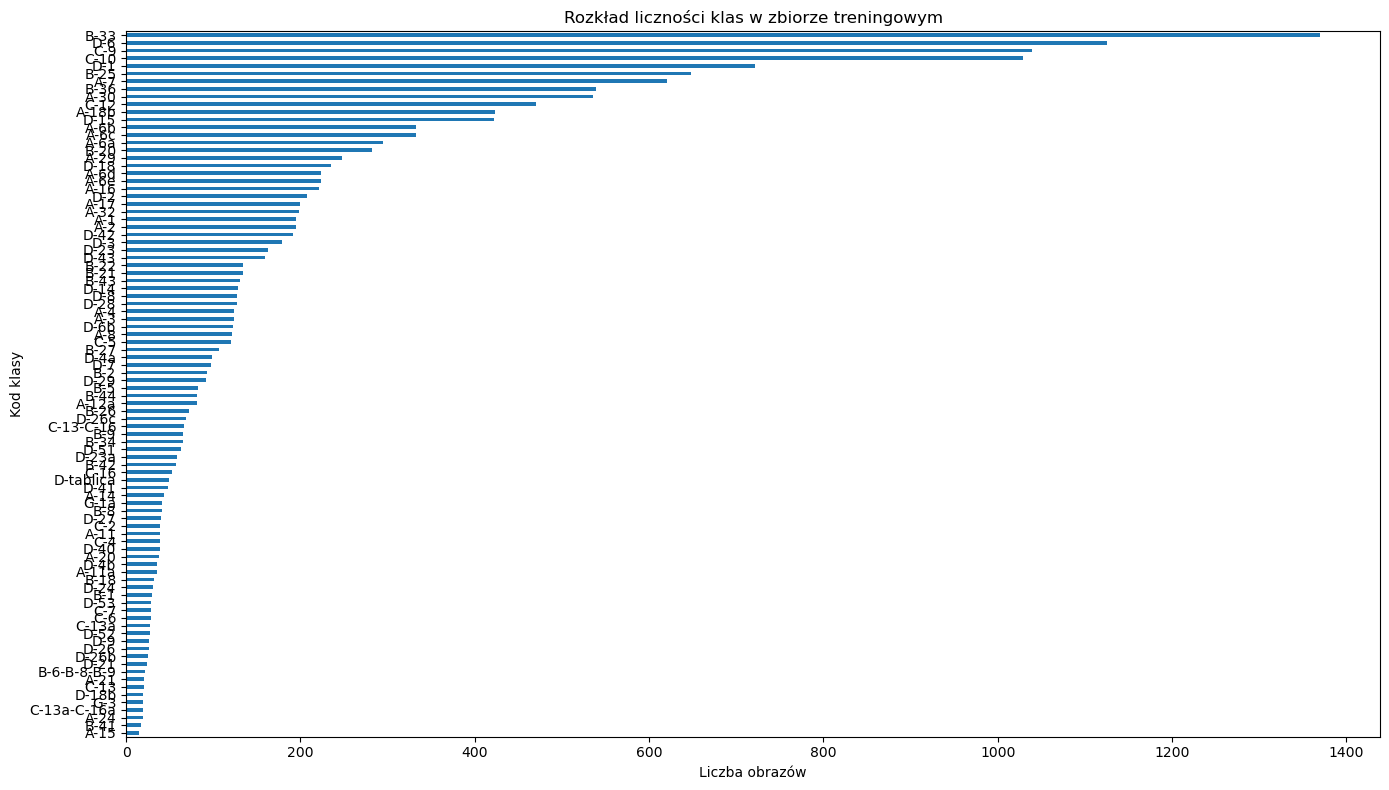

In [5]:
fig, ax = plt.subplots(figsize=(14, 8))

train_counts.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title("Rozkład liczności klas w zbiorze treningowym")
ax.set_xlabel("Liczba obrazów")
ax.set_ylabel("Kod klasy")

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "01_class_distribution_train.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

Zbiór treningowy charakteryzuje się znacznym zróżnicowaniem liczności klas. Różnica pomiędzy najmniej i najliczniej reprezentowaną klasą wskazuje na konieczność uwzględnienia niezbalansowania podczas procesu uczenia.

Nie stosuje się redukcji wszystkich klas do liczności klasy najmniejszej, ponieważ prowadziłoby to do istotnej utraty dostępnych informacji.

## 4. Kontrola poprawności plików i parametrów technicznych obrazów

In [6]:
def inspect_image(path_str: str):
    result = {
        "read_ok": False,
        "width": np.nan,
        "height": np.nan,
        "channels": np.nan,
        "mode": None,
        "mean_brightness": np.nan,
        "median_brightness": np.nan,
        "std_brightness": np.nan,
        "dark_pixel_ratio": np.nan,
        "bright_pixel_ratio": np.nan
    }

    try:
        with Image.open(path_str) as image:
            image.load()

            result["read_ok"] = True
            result["width"], result["height"] = image.size
            result["channels"] = len(image.getbands())
            result["mode"] = image.mode

            array = np.asarray(
                image.convert("RGB"),
                dtype=np.float32
            )

            luminance = (
                0.2126 * array[:, :, 0]
                + 0.7152 * array[:, :, 1]
                + 0.0722 * array[:, :, 2]
            )

            result["mean_brightness"] = float(luminance.mean())
            result["median_brightness"] = float(np.median(luminance))
            result["std_brightness"] = float(luminance.std())
            result["dark_pixel_ratio"] = float(
                (luminance <= 20).mean()
            )
            result["bright_pixel_ratio"] = float(
                (luminance >= 245).mean()
            )

    except Exception:
        pass

    return result


image_stats = [
    inspect_image(path)
    for path in tqdm(
        df["path"],
        desc="Analiza obrazów"
    )
]

df_full = pd.concat(
    [
        df.reset_index(drop=True),
        pd.DataFrame(image_stats)
    ],
    axis=1
)

print(
    "Poprawnie odczytane:",
    int(df_full["read_ok"].sum())
)

print(
    "Błędy odczytu:",
    int((~df_full["read_ok"]).sum())
)

Analiza obrazów:   0%|          | 0/21044 [00:00<?, ?it/s]

Poprawnie odczytane: 21044
Błędy odczytu: 0


Najczęściej występujące rozdzielczości


,width,height,count
766,45,49,66
922,49,49,60
1085,53,51,60
845,47,49,56
926,49,53,54
1004,51,53,54
920,49,47,52
843,47,47,51
1006,51,55,50
1173,55,55,48


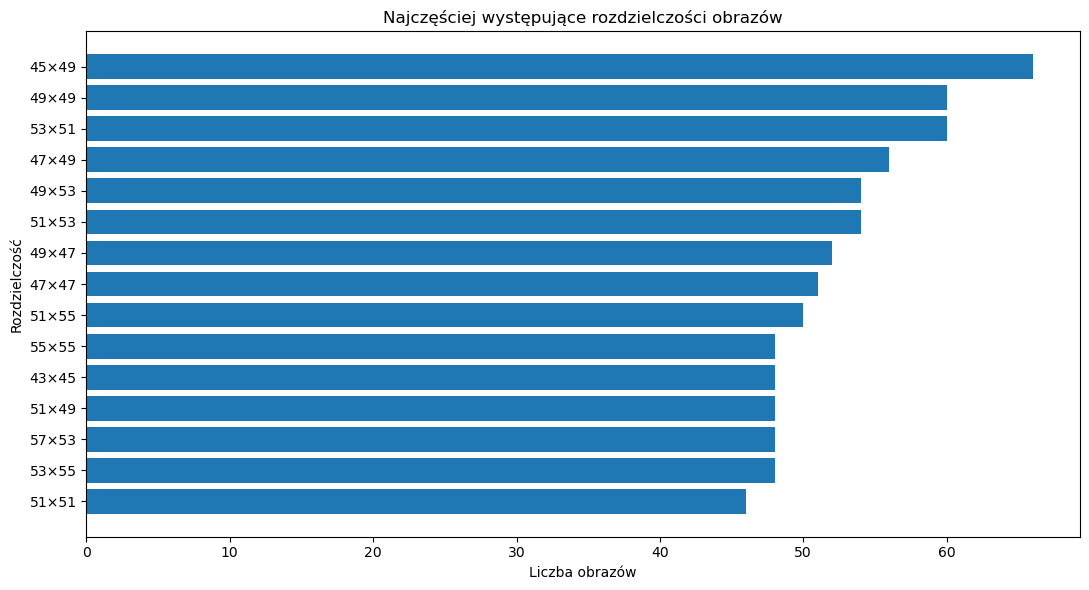

In [7]:
resolution_summary = (
    df_full[df_full["read_ok"]]
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Najczęściej występujące rozdzielczości")
display(resolution_summary.head(20))

resolution_summary.to_csv(
    METADATA_DIR / "03_resolution_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

top_resolutions = resolution_summary.head(15).copy()

top_resolutions["resolution"] = (
    top_resolutions["width"].astype(int).astype(str)
    + "×"
    + top_resolutions["height"].astype(int).astype(str)
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    top_resolutions["resolution"].iloc[::-1],
    top_resolutions["count"].iloc[::-1]
)

ax.set_title("Najczęściej występujące rozdzielczości obrazów")
ax.set_xlabel("Liczba obrazów")
ax.set_ylabel("Rozdzielczość")

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "02_image_resolutions.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

Wszystkie obrazy zostały poddane kontroli poprawności odczytu. Zróżnicowanie rozdzielczości uzasadnia zastosowanie jednolitego rozmiaru wejściowego w transformacjach wykonywanych przed podaniem obrazów do modeli.

## 5. Charakterystyka jasności

Średnia jasność i odchylenie standardowe jasności są wykorzystywane jako miary opisujące zróżnicowanie warunków obrazu.

Miary te opisują właściwości obrazu i nie są traktowane jako bezpośrednie etykiety warunków środowiskowych.

Statystyki średniej jasności


count    21044.000000
mean       113.542230
std         41.506706
min         10.503909
25%         82.941040
50%        112.749027
75%        143.589046
max        245.255142
Name: mean_brightness, dtype: float64

Statystyki odchylenia standardowego jasności


count    21044.000000
mean        56.179496
std         16.368845
min          5.355133
25%         45.471486
50%         57.554787
75%         67.882721
max        107.801598
Name: std_brightness, dtype: float64

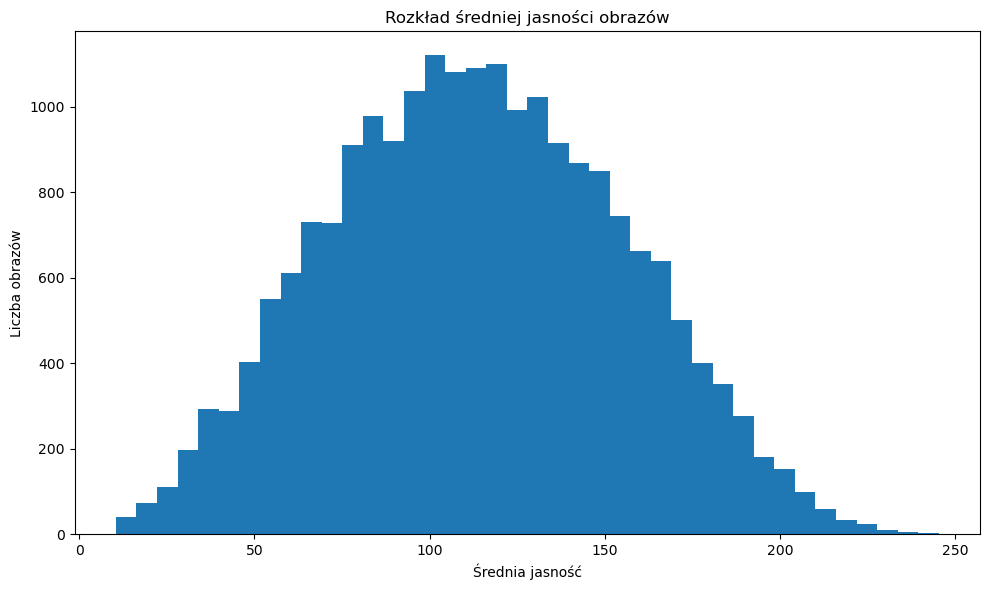

In [8]:
valid = df_full[df_full["read_ok"]].copy()

print("Statystyki średniej jasności")
display(valid["mean_brightness"].describe())

print("Statystyki odchylenia standardowego jasności")
display(valid["std_brightness"].describe())

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    valid["mean_brightness"],
    bins=40
)

ax.set_title("Rozkład średniej jasności obrazów")
ax.set_xlabel("Średnia jasność")
ax.set_ylabel("Liczba obrazów")

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_mean_brightness_distribution.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

In [9]:
class_lighting = (
    valid.groupby("class_code")
    .agg(
        images=("path", "count"),
        mean_brightness=("mean_brightness", "mean"),
        median_brightness=("median_brightness", "mean"),
        brightness_std=("std_brightness", "mean"),
        dark_ratio=("dark_pixel_ratio", "mean"),
        bright_ratio=("bright_pixel_ratio", "mean")
    )
    .sort_values("mean_brightness")
)

print("Klasy o najniższej średniej jasności")
display(class_lighting.head(10))

print("Klasy o najwyższej średniej jasności")
display(class_lighting.tail(10))

class_lighting.to_csv(
    METADATA_DIR / "04_class_lighting_summary.csv",
    encoding="utf-8-sig"
)

Klasy o najniższej średniej jasności


,images,mean_brightness,median_brightness,brightness_std,dark_ratio,bright_ratio
class_code,,,,,,
C-13a,34,73.997068,57.306153,43.279635,0.057880,0.011974
C-13,26,77.500940,59.906854,53.727638,0.123755,0.037763
D-40,50,79.793988,54.572940,50.691787,0.055899,0.009524
D-7,125,80.295314,52.433105,53.267796,0.056339,0.011160
D-8,160,81.005123,59.580226,49.581841,0.084301,0.007638
D-21,31,81.574216,60.753906,46.145424,0.030883,0.010184
D-3,226,85.020013,62.392925,49.993329,0.076306,0.013111
C-13a-C-16a,25,85.511199,63.553452,56.326072,0.089846,0.020500
C-13-C-16,84,87.504547,68.677922,54.486337,0.107710,0.021415


Klasy o najwyższej średniej jasności


,images,mean_brightness,median_brightness,brightness_std,dark_ratio,bright_ratio
class_code,,,,,,
D-2,261,140.400062,135.678643,64.547161,0.056152,0.120964
B-34,82,141.504635,143.061659,58.110076,0.040105,0.042125
B-9,82,142.193976,147.165234,56.115897,0.014894,0.056368
D-1,903,142.506869,141.409782,50.596375,0.033940,0.072714
A-8,152,142.521475,141.019201,59.823186,0.021075,0.047331
A-24,25,145.666400,142.533686,61.730083,0.022265,0.061380
B-44,102,148.739254,164.498124,58.946765,0.039041,0.059916
D-52,35,151.992010,176.143547,59.473107,0.050752,0.022512
D-53,37,156.579789,176.158765,54.997058,0.011521,0.074670


Zmienność poziomu jasności występująca w zbiorze stanowi podstawę do późniejszego badania odporności modeli na różne warunki wejściowe. Analiza zostanie wykorzystana do zaprojektowania eksperymentu dotyczącego wpływu oświetlenia na skuteczność klasyfikacji.

## 6. Wizualna kontrola obrazów

Celem jest ocena, czy charakterystyki jasności odpowiadają obserwowanym różnicom wizualnym.

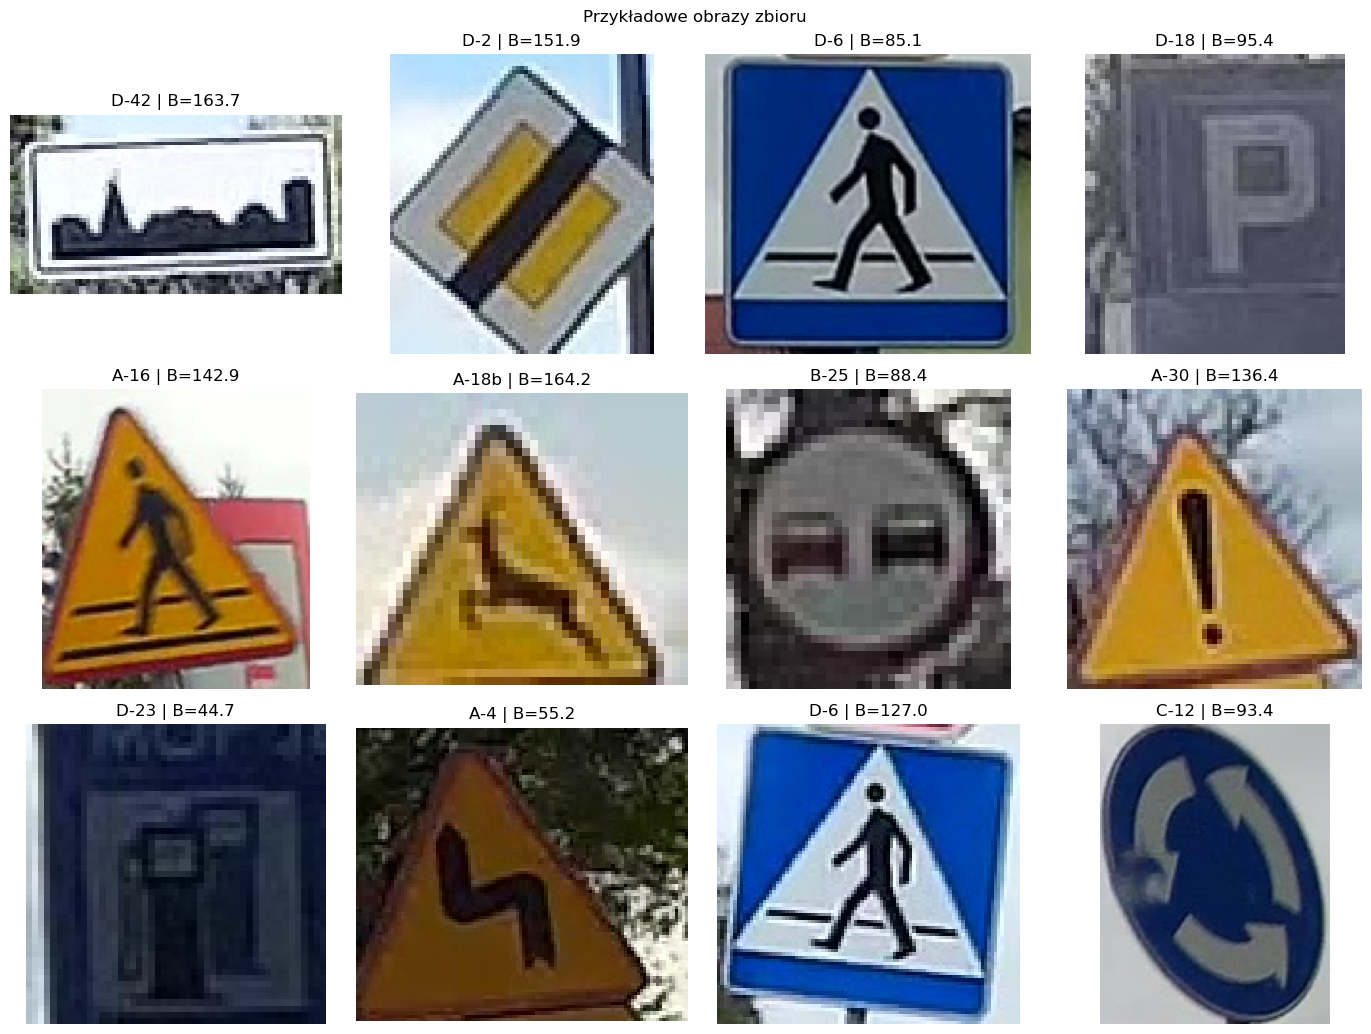

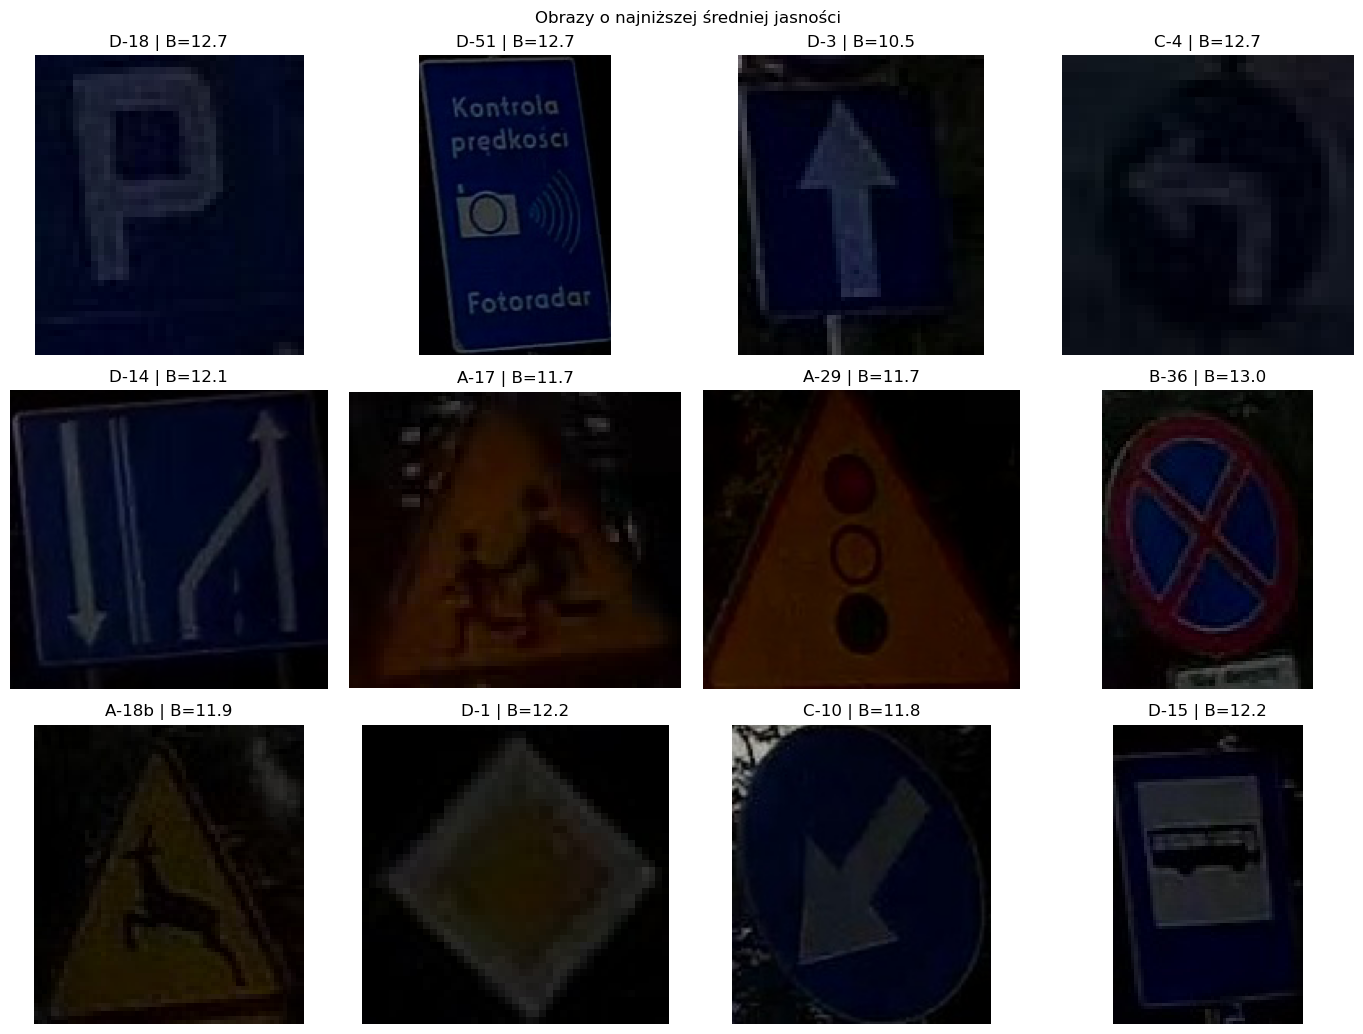

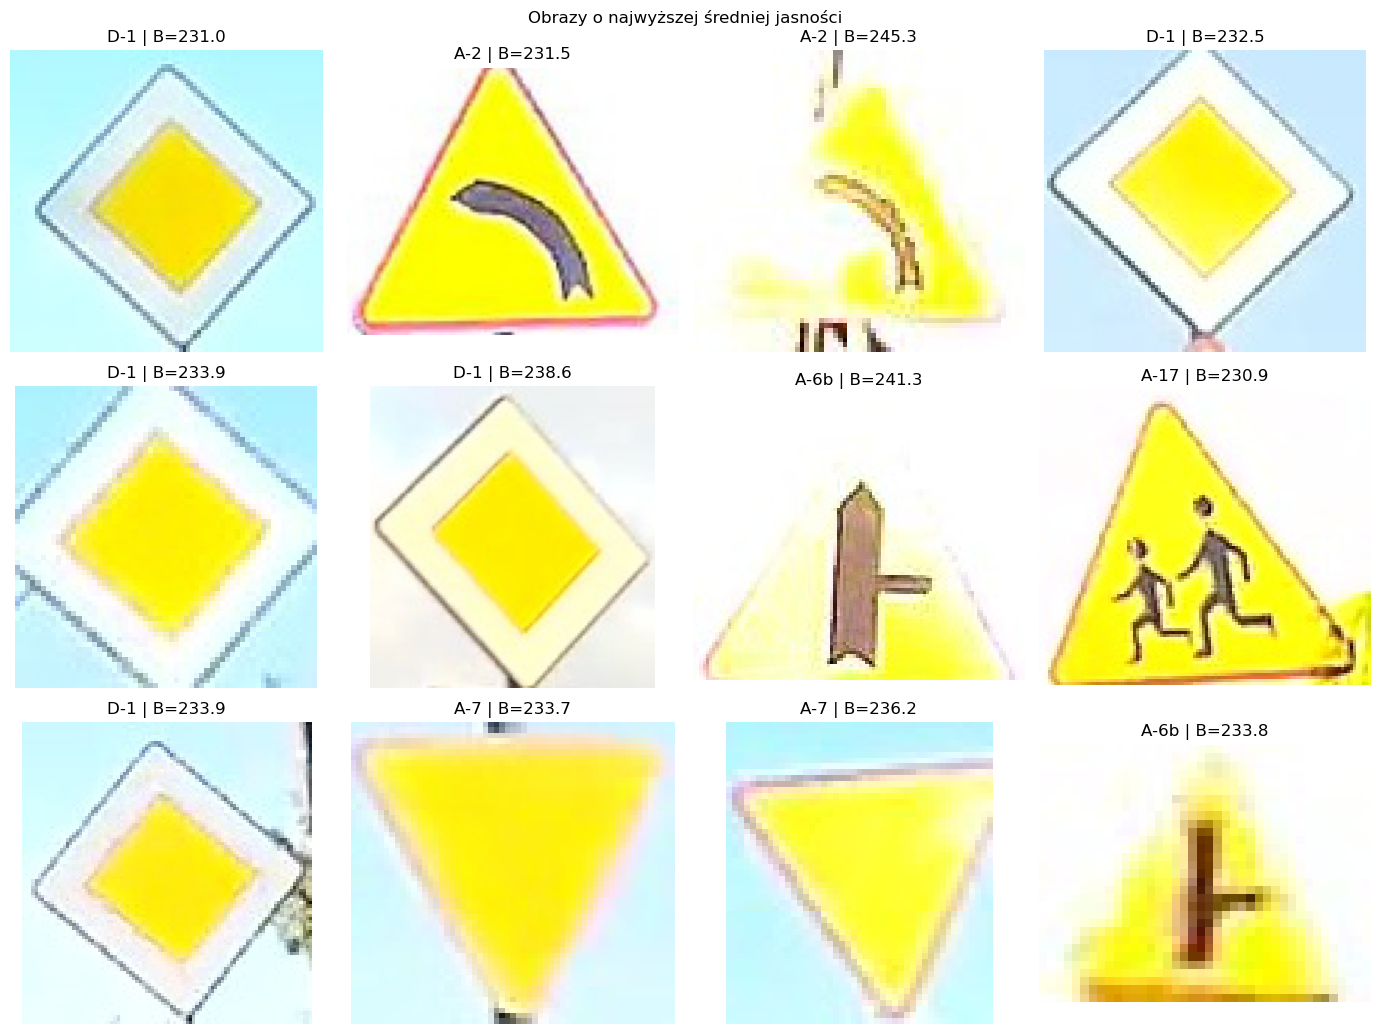

In [10]:
def show_grid(dataframe, title, n=12, seed=42):
    sample = dataframe.sample(
        min(n, len(dataframe)),
        random_state=seed
    )

    columns = 4
    rows = math.ceil(len(sample) / columns)

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(14, 3.5 * rows)
    )

    axes = np.asarray(axes).reshape(-1)

    for axis, (_, row) in zip(
        axes,
        sample.iterrows()
    ):
        try:
            image = Image.open(
                row["path"]
            ).convert("RGB")

            axis.imshow(image)

            axis.set_title(
                f'{row["class_code"]} | '
                f'B={row["mean_brightness"]:.1f}'
            )

        except Exception:
            axis.set_title("Błąd odczytu")

        axis.axis("off")

    for axis in axes[len(sample):]:
        axis.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_grid(
    valid,
    "Przykładowe obrazy zbioru",
    n=12
)

show_grid(
    valid.nsmallest(12, "mean_brightness"),
    "Obrazy o najniższej średniej jasności",
    n=12
)

show_grid(
    valid.nlargest(12, "mean_brightness"),
    "Obrazy o najwyższej średniej jasności",
    n=12
)

## 7. Kontrola identycznych duplikatów

Celem jest wykrycie identycznych plików oraz identyfikacja obrazów występujących równocześnie w oryginalnym zbiorze treningowym i testowym.

In [11]:
def sha256_file(path: Path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()

    with path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


df_full["sha256"] = [
    sha256_file(Path(path))
    for path in tqdm(
        df_full["path"],
        desc="Obliczanie SHA-256"
    )
]

duplicate_groups = (
    df_full.groupby("sha256")
    .size()
)

duplicate_groups = duplicate_groups[
    duplicate_groups > 1
]

cross_split_groups = (
    df_full.groupby("sha256")["source_split"]
    .nunique()
)

cross_split_groups = cross_split_groups[
    cross_split_groups > 1
]

print(
    "Grupy identycznych plików:",
    len(duplicate_groups)
)

print(
    "Obrazy w grupach duplikatów:",
    int(duplicate_groups.sum())
)

print(
    "Grupy występujące w TRAIN i TEST:",
    len(cross_split_groups)
)

Obliczanie SHA-256:   0%|          | 0/21044 [00:00<?, ?it/s]

Grupy identycznych plików: 129
Obrazy w grupach duplikatów: 259
Grupy występujące w TRAIN i TEST: 1


In [12]:
duplicate_details = df_full[
    df_full["sha256"].isin(
        duplicate_groups.index
    )
].sort_values("sha256")

cross_split_details = df_full[
    df_full["sha256"].isin(
        cross_split_groups.index
    )
].sort_values("sha256")

duplicate_details.to_csv(
    METADATA_DIR / "05_duplicate_details.csv",
    index=False,
    encoding="utf-8-sig"
)

cross_split_details.to_csv(
    METADATA_DIR / "06_cross_split_duplicates.csv",
    index=False,
    encoding="utf-8-sig"
)

display(
    cross_split_details[
        [
            "sha256",
            "source_split",
            "class_code",
            "path"
        ]
    ]
)

,sha256,source_split,class_code,path
16637,a6296801d4cacf34f94c646ecac708f3cba94a09cf5d86...,train_original,D-tablica,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
16638,a6296801d4cacf34f94c646ecac708f3cba94a09cf5d86...,train_original,D-tablica,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
21027,a6296801d4cacf34f94c646ecac708f3cba94a09cf5d86...,test_original,D-tablica,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...


Identyczne obrazy występujące równocześnie w zbiorze treningowym i testowym stanowią potencjalny przeciek danych.
Aby zachować niezależność końcowej oceny, kopia znajdująca się w zbiorze treningowym zostanie wykluczona z procesu uczenia.

## 8. Przygotowanie manifestów eksperymentalnych

Oryginalny `test` zostaje zachowany jako niezależny zbiór końcowej oceny.

Oryginalny `train` jest dzielony na `train` i `validation`.

Obrazy nie są kopiowane ani przenoszone. Kolejne eksperymenty korzystają z manifestów CSV zawierających ścieżki do obrazów.

In [13]:
train_original = df_full[
    df_full["source_split"] == "train_original"
].copy()

test_original = df_full[
    df_full["source_split"] == "test_original"
].copy()

if len(cross_split_groups):
    train_clean = train_original[
        ~train_original["sha256"].isin(
            cross_split_groups.index
        )
    ].copy()
else:
    train_clean = train_original.copy()

train_part, validation_part = train_test_split(
    train_clean,
    test_size=VALIDATION_RATIO,
    random_state=RANDOM_SEED,
    stratify=train_clean["class_code"]
)

train_part = train_part.copy()
validation_part = validation_part.copy()
test_original = test_original.copy()

train_part["split"] = "train"
validation_part["split"] = "validation"
test_original["split"] = "test_final"

manifest = pd.concat(
    [
        train_part,
        validation_part,
        test_original
    ],
    ignore_index=True
)

print("TRAIN:", len(train_part))
print("VALIDATION:", len(validation_part))
print("TEST_FINAL:", len(test_original))

TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


In [14]:
train_part.to_csv(
    METADATA_DIR / "07_train.csv",
    index=False,
    encoding="utf-8-sig"
)

validation_part.to_csv(
    METADATA_DIR / "08_validation.csv",
    index=False,
    encoding="utf-8-sig"
)

test_original.to_csv(
    METADATA_DIR / "09_test_final.csv",
    index=False,
    encoding="utf-8-sig"
)

manifest.to_csv(
    METADATA_DIR / "10_dataset_manifest.csv",
    index=False,
    encoding="utf-8-sig"
)

df_full.to_csv(
    METADATA_DIR / "11_full_image_inventory_with_features.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Manifesty zapisane w:", METADATA_DIR)

Manifesty zapisane w: C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\data\data\processed\metadata


## 9. Charakterystyka przygotowanych zbiorów

Sprawdzenie liczności klas po utworzeniu zbiorów `train`, `validation` i `test_final`.

split,test_final,train,validation
class_code,,,
A-1,50,166,29
A-11,11,33,6
A-11a,10,30,5
A-12a,21,69,12
A-14,11,37,6
...,...,...,...
D-8,33,108,19
D-9,8,22,4
D-tablica,15,40,7


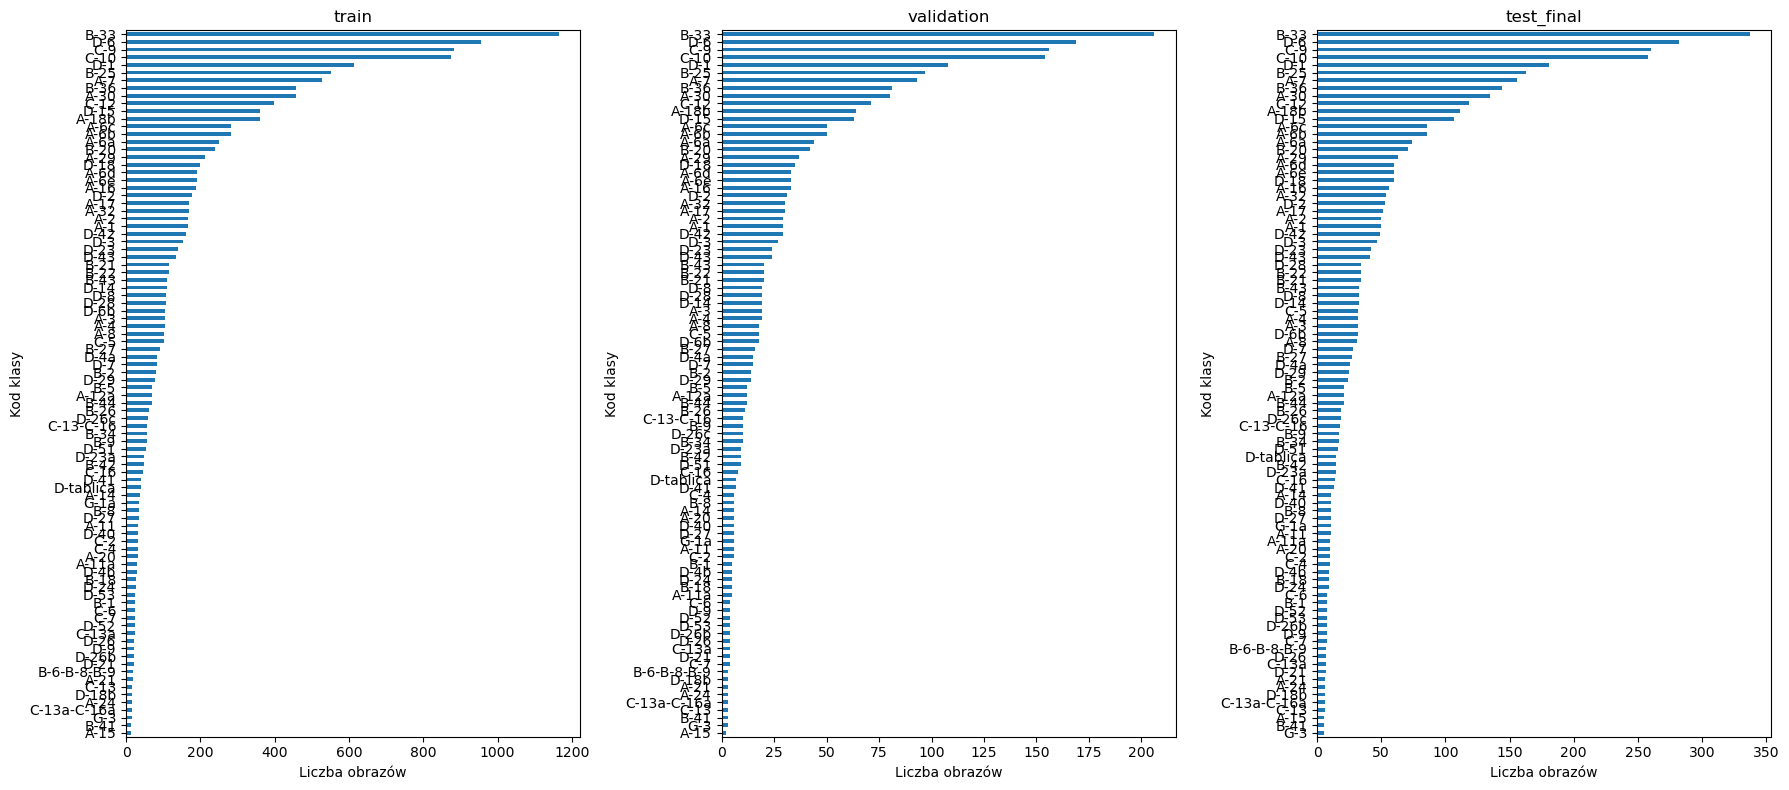

In [15]:
prepared_counts = (
    manifest.groupby(
        ["split", "class_code"]
    )
    .size()
    .unstack("split")
    .fillna(0)
    .astype(int)
)

display(
    prepared_counts.sort_index()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 8)
)

for axis, split_name in zip(
    axes,
    ["train", "validation", "test_final"]
):
    if split_name in prepared_counts.columns:
        prepared_counts[
            split_name
        ].sort_values().plot(
            kind="barh",
            ax=axis
        )

    axis.set_title(split_name)
    axis.set_xlabel("Liczba obrazów")
    axis.set_ylabel("Kod klasy")

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "04_prepared_split_distributions.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

Oryginalny zbiór testowy zostaje zachowany jako niezależny zbiór końcowej oceny.

Oryginalny zbiór treningowy jest dzielony na `train` i `validation`.

Niezbalansowanie klas nie jest eliminowane poprzez redukcję liczby przykładów. W kolejnym etapie zostaną porównane metody kompensacji niezbalansowania na poziomie procesu uczenia.

## 10. Raport zbiorczy

Najważniejsze wyniki audytu są zapisywane w raporcie JSON. Tabele szczegółowe i wykresy są przechowywane w katalogach wynikowych projektu.

In [16]:
audit_summary = {
    "dataset_root": str(SOURCE_DATASET_ROOT),
    "total_images": int(len(df_full)),
    "classes": int(df_full["class_code"].nunique()),
    "read_errors": int((~df_full["read_ok"]).sum()),
    "exact_duplicate_groups": int(len(duplicate_groups)),
    "images_in_duplicate_groups": int(duplicate_groups.sum()),
    "cross_split_duplicate_groups": int(len(cross_split_groups)),
    "original_train_images": int(len(train_original)),
    "train_after_leakage_control": int(len(train_clean)),
    "validation_images": int(len(validation_part)),
    "test_final_images": int(len(test_original)),
    "validation_ratio": VALIDATION_RATIO,
    "random_seed": RANDOM_SEED,
    "train_min_class_count": int(train_counts.min()),
    "train_median_class_count": float(train_counts.median()),
    "train_max_class_count": int(train_counts.max()),
    "test_min_class_count": int(test_counts.min()),
    "test_median_class_count": float(test_counts.median()),
    "test_max_class_count": int(test_counts.max())
}

report_path = REPORTS_DIR / "dataset_audit_summary.json"

report_path.write_text(
    json.dumps(
        audit_summary,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

print(
    json.dumps(
        audit_summary,
        indent=2,
        ensure_ascii=False
    )
)

{
  "dataset_root": "C:\\Users\\Dell\\Desktop\\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\\KB_Praca_Magisterska\\data\\raw\\polish_traffic_signs_dataset",
  "total_images": 21044,
  "classes": 92,
  "read_errors": 0,
  "exact_duplicate_groups": 129,
  "images_in_duplicate_groups": 259,
  "cross_split_duplicate_groups": 1,
  "original_train_images": 16746,
  "train_after_leakage_control": 16744,
  "validation_images": 2512,
  "test_final_images": 4298,
  "validation_ratio": 0.15,
  "random_seed": 42,
  "train_min_class_count": 15,
  "train_median_class_count": 87.0,
  "train_max_class_count": 1370,
  "test_min_class_count": 5,
  "test_median_class_count": 22.5,
  "test_max_class_count": 337
}
